In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from PIL import Image  # For GIF creation
import os
import warnings

import numpy as np
import pandas as pd
import skimage
import torch

import neuralpredictors

warnings.filterwarnings("ignore")

from nnfabrik.builder import get_data, get_model, get_trainer
from sensorium.utility.scores import get_correlations, get_poisson_loss
from nnfabrik.utility.nn_helpers import set_random_seed

In [2]:
seed = 42
set_random_seed(seed)

starting_epcoch = 1
multiplier = 100000.0
exponent=2.0
clusters=5
alpha=2.1
pretrain_epoch = 30
lr_model=0.002
#model_checkpoints/sensorium_model_dec_KL_EM_diagcov_exp_2_cluster_2_mult_4000000000.0_reg_adlognorm_se1.pth
path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{clusters}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}'
#path_ending = 'without_KL_sedd_10'

In [3]:
seed = 42
set_random_seed(seed)
torch.cuda.is_available()
cuda_number = 6
torch.cuda.set_device(f"cuda:{cuda_number}")


# loading the SENSORIUM+ dataset
pre = "/usr/users/agecker/datasets/sensorium_2022_pictures/real_dataset/"
filenames = [f"{pre}{i}/" for i in os.listdir(pre)]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
    "seed": seed,
}

dataloaders = get_data(dataset_fn, dataset_config)
model_fn = 'sensorium.models.stacked_core_full_gauss_readout'
model_config = {'pad_input': False,
  'stack': -1,
  'layers': 4,
  'input_kern': 9,
  'gamma_input': 6.3831,
  'gamma_readout': 10,
  'hidden_kern': 7,
  'hidden_channels': 128,
  'depth_separable': True,
  'grid_mean_predictor': {
    'type': 'cortex',
    'input_dimensions': 2,
    'hidden_layers': 1,
    'hidden_features': 30,
    'final_tanh': True
   },
  'init_sigma': 0.1,
  'init_mu_range': 0.3,
  'gauss_type': 'full',
  'shifter': True,
  'regularizer_type': 'adaptive_log_norm',
  #'feature_reg_weight': 10,
}
model = get_model(
    model_fn=model_fn,
    model_config=model_config,
    dataloaders=dataloaders,
    seed=seed,
)

In [4]:
exponent=2.0
lr_model = 0.008
pretrain_epoch = 10
alpha = 2.1
cluster =20
multiplier = 10000.0
seed =42
device = f"cuda:{cuda_number}"

path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_{path_ending}.pth'
model.load_state_dict(torch.load(save_path),strict=False)
validation_correlation = get_correlations(
    model,
    dataloaders["validation"],
    device=device,
    as_dict=False,
    per_neuron=False,
)
validation_correlation

np.float32(0.40956843)

In [5]:
device = f"cuda:{cuda_number}"
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_without_KL_seed_42.pth'
model.load_state_dict(torch.load(save_path),strict=False)
validation_correlation = get_correlations(
    model,
    dataloaders["validation"],
    device=device,
    as_dict=False,
    per_neuron=False,
)
validation_correlation

np.float32(0.40928435)

In [6]:
device = f"cuda:{cuda_number}"
exponents = np.array([1.0,1.2,1.4,1.6,1.7,1.8,1.9,2.5,3.0])
cluster_numbers = np.array([10])
#,5,7,9,11,13,15,17,19,20,22,24,25,26,27,28,29,30,40,50])
dec_starting_epochs = np.array([8,9,11,12,13,14,15])


exponent=2.0
pretrain_epoch=10
lr_model = 0.008
multiplier = 100000.0
cluster=15

clusters = range(5,55,5)

pretrain_epochs = np.array([10,20,30,40])
alpha = 2.1
validation_correlation_dict = {}
learning_rates = np.array([0.001, 0.002, 0.003, 0.004, 0.005, 0.006,0.007,0.008,0.009])

keys1 = np.array([1e4,5e4,1e5])
keys2 = clusters

#for alpha in alphas:
for k1 in keys1:
    '''
    if pretrain_epoch == 5:
        multiplier = 1000000.0
    else:
        multiplier = 100000.0'
    '''
    multiplier=k1
    validation_correlation_dict[k1] = {}
    for k2 in keys2:
        '''
        if pretrain_epoch == 10:
            path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}'
        else:'
        '''
        cluster=k2
        path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
        save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_{path_ending}.pth'
        if not os.path.exists(save_path):
            print(f"Warning: Model file not found for {save_path}. Inserting None.")
            validation_correlation_dict[k1][k2] = None
            continue  # Skip this iteration
        model.load_state_dict(torch.load(save_path),strict=False)
        validation_correlation = get_correlations(
            model,
            dataloaders["validation"],
            device=device,
            as_dict=False,
            per_neuron=False,
        )
        validation_correlation_dict[k1][k2] = (validation_correlation)


Text(0.5, 1.0, 'Validation correlation vs. clusters for fixed pretrained epochs')

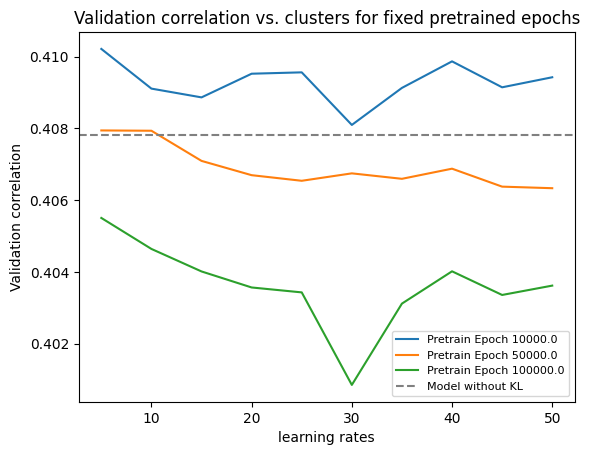

In [7]:
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_without_KL_seed_100.pth'
model.load_state_dict(torch.load(save_path),strict=False)
validation_correlation_woKL = get_correlations(
    model,
    dataloaders["validation"],
    device=device,
    as_dict=False,
    per_neuron=False,
)

for k1 in keys1:
    clusters_sorted = sorted(validation_correlation_dict[k1].keys())  # Ensure sorted order
    correlation_values = [validation_correlation_dict[k1][k2] for k2 in keys2]

    # Plot
    plt.plot(clusters_sorted, correlation_values, label=f'Pretrain Epoch {k1}')
    #plt.plot(clusters, validation_correlation_dict[pretrain_epoch][:], label= f'{pretrain_epoch}')
#plt.plot(alphas, validation_correlations_40, label= 'PE 40')
plt.axhline(y=validation_correlation_woKL, color="gray", linestyle="--", label="Model without KL")
plt.legend(loc='lower right', fontsize=8)
plt.xlabel('learning rates')
plt.ylabel('Validation correlation')
plt.title(f'Validation correlation vs. clusters for fixed pretrained epochs')
          # {pretrain_epoch} base_mult {multiplier}')

In [ ]:
device = f"cuda:{cuda_number}"
exponents = np.array([1.0,1.2,1.4,1.6,1.7,1.8,1.9,2.5,3.0])
cluster_numbers = np.array([10])
#,5,7,9,11,13,15,17,19,20,22,24,25,26,27,28,29,30,40,50])
dec_starting_epochs = np.array([8,9,11,12,13,14,15])
multiplier = 100000.0
exponent=2.0
cluster=15
alpha=2.1
pretrain_epoch = 30
validation_correlations_30=[]
validation_correlations_40= []
learning_rates = np.array([0.002])
alphas = np.array([2.1,2.5,5,10])
clusters = list(range(5,10)) + list(range(10, 65, 5))
seed = 10

for pretrain_epoch in pretrain_epochs:
    if pretrain_epoch == 10:
        lr_model = 0.005
    else:
        multiplier = 100000.0
        lr_model= 0.003
    validation_correlation_dict[pretrain_epoch] = {}
    #for cluster in clusters:
    for cluster in clusters:
        path_ending = f'KL_EM_diagcov_alpha_{alpha}_exp_{exponent}_cluster_{cluster}_mult_{multiplier}_reg_adlognorm_pe{pretrain_epoch}_lr_{lr_model}_seed_{seed}'
        save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_{path_ending}.pth'
        if not os.path.exists(save_path):
            print(f"Warning: Model file not found for {save_path}. Inserting None.")
            validation_correlation_dict[pretrain_epoch][lr_model] = None
            continue  # Skip this iteration
        model.load_state_dict(torch.load(save_path),strict=False)
        validation_correlation = get_correlations(
            model,
            dataloaders["validation"],
            device=device,
            as_dict=False,
            per_neuron=False,
        )
        validation_correlation_dict[pretrain_epoch][cluster] = (validation_correlation)


Text(0.5, 1.0, 'Validation correlation vs. clusters for fixed pretrained epochs')

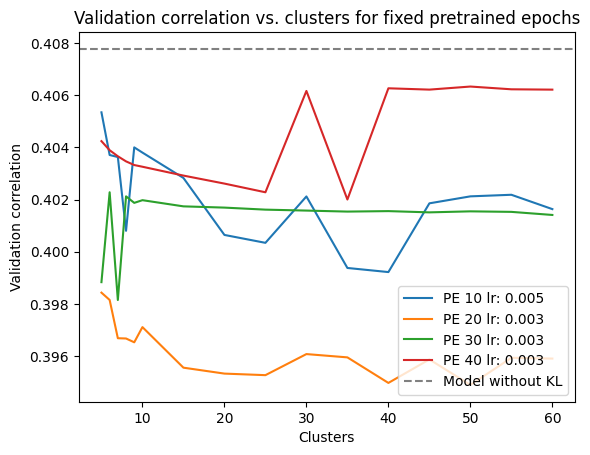

In [38]:
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_without_KL_seed_100.pth'
model.load_state_dict(torch.load(save_path),strict=False)
validation_correlation_woKL = get_correlations(
    model,
    dataloaders["validation"],
    device=device,
    as_dict=False,
    per_neuron=False,
)

for pretrain_epoch in pretrain_epochs:
    if pretrain_epoch == 10:
        lr_model = 0.005
    else:
        #multiplier = 100000.0
        lr_model= 0.003
    clusters_sorted = sorted(validation_correlation_dict[pretrain_epoch].keys())  # Ensure sorted order
    correlation_values = [validation_correlation_dict[pretrain_epoch][c] for c in clusters_sorted]

    # Plot
    plt.plot(clusters_sorted, correlation_values, label=f'PE {pretrain_epoch} lr: {lr_model}')
    #plt.plot(clusters, validation_correlation_dict[pretrain_epoch][:], label= f'{pretrain_epoch}')
#plt.plot(alphas, validation_correlations_40, label= 'PE 40')
plt.axhline(y=validation_correlation_woKL, color="gray", linestyle="--", label="Model without KL")
plt.legend(loc='lower right', fontsize=10)
plt.xlabel('Clusters')
plt.ylabel('Validation correlation')
plt.title(f'Validation correlation vs. clusters for fixed pretrained epochs')
          # {pretrain_epoch} base_mult {multiplier}')

In [25]:
save_path = f'/user/ninasophie.nellen/sensorium/tests/model_checkpoints/sensorium_model_dec_without_KL_seed_100.pth'
model.load_state_dict(torch.load(save_path),strict=False)
validation_correlation = get_correlations(
    model,
    dataloaders["validation"],
    device=device,
    as_dict=False,
    per_neuron=False,
)
validation_correlation

np.float32(0.40784422)

[ 2.1  2.5  5.  10. ]


Text(0.5, 1.0, 'Validation correlation vs. learning rate for fixed pretrained epoch 40 base_mult 100000.0')

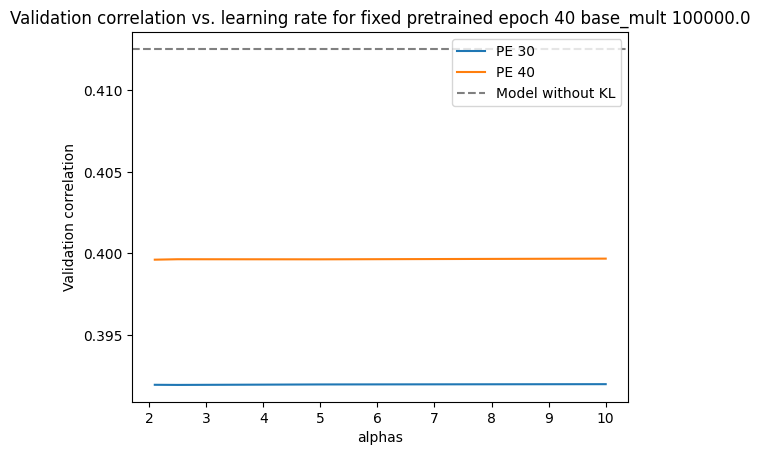

In [18]:
print(alphas)
plt.plot(alphas, validation_correlations_30, label= 'PE 30')
plt.plot(alphas, validation_correlations_40, label= 'PE 40')
plt.axhline(y=0.412546, color="gray", linestyle="--", label="Model without KL")
plt.legend(loc='upper right')
plt.xlabel('alphas')
plt.ylabel('Validation correlation')
plt.title(f'Validation correlation vs. learning rate for fixed pretrained epoch {pretrain_epoch} base_mult {multiplier}')
#plt.savefig(f'validation_correlations/validation_correlation_vs_lr_for_pe_{pretrain_epoch}.png', dpi=300, bbox_inches='tight')

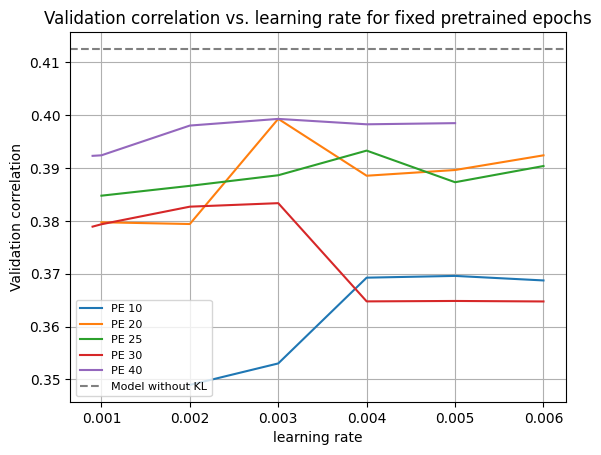

In [45]:
for pe in [10, 20, 25, 30, 40]:
    var_name = f"validation_correlation_pe{pe}"
    
    if var_name in globals():  # Check if the variable exists
        plt.plot(learning_rates, globals()[var_name], label=f"PE {pe}")  # Plot with label
    else:
        print(f"{var_name} not found, skipping...")

plt.axhline(y= 0.412546, color="gray", linestyle="--", label="Model without KL")
plt.legend(fontsize=8, loc='lower left')
plt.xlabel('learning rate')
plt.ylabel('Validation correlation')
plt.title(f'Validation correlation vs. learning rate for fixed pretrained epochs')

plt.grid(True)  # Add grid for better readability

# Show the plot
plt.show()

In [13]:
clusters_list = ["Without KL"] + cluster_numbers.tolist()
exponents_list = ["Without KL"] + exponents.tolist()
learning_rates = ["Without KL"] + learning_rates.tolist()

reference_value = validation_correlations[0]  # Without KL as reference
differences = [val - reference_value for val in validation_correlations]

# Create the table as a pandas DataFrame
data = {
    #"Cluster": clusters_list,
    "learning_rates": (learning_rates),
    "Validation Correlation": validation_correlations,
    #"Difference from Reference": differences,
}
table = pd.DataFrame(data)

latex_table = table.to_latex(index=False, header=True)
print(latex_table)
# Print the table
print(table)

\begin{tabular}{lr}
\toprule
learning_rates & Validation Correlation \\
\midrule
Without KL & 0.412546 \\
0.000900 & 0.392312 \\
0.001000 & 0.392411 \\
0.002000 & 0.398042 \\
0.003000 & 0.399303 \\
0.004000 & 0.398281 \\
0.005000 & 0.398500 \\
\bottomrule
\end{tabular}

  learning_rates  Validation Correlation
0     Without KL                0.412546
1         0.0009                0.392312
2          0.001                0.392411
3          0.002                0.398042
4          0.003                0.399303
5          0.004                0.398281
6          0.005                0.398500


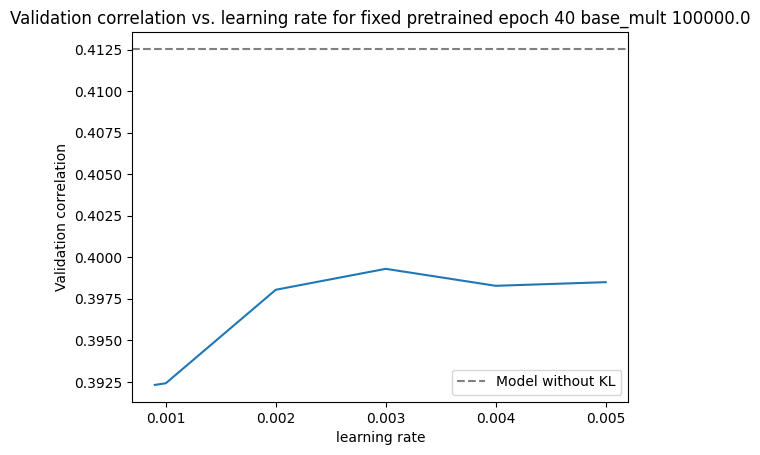

In [14]:
plt.plot(learning_rates[1:], validation_correlations[1:])
plt.axhline(y=validation_correlations[0], color="gray", linestyle="--", label="Model without KL")
plt.legend()
plt.xlabel('learning rate')
plt.ylabel('Validation correlation')
plt.title(f'Validation correlation vs. learning rate for fixed pretrained epoch {pretrain_epoch} base_mult {multiplier}')
plt.savefig(f'validation_correlations/validation_correlation_vs_lr_for_pe_{pretrain_epoch}.png', dpi=300, bbox_inches='tight')